# (Sentiment Analysis) Text Classification with RNN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# print(f"TensorFlow: {tf.__version__}")
# print(f"GPUs      : {tf.config.list_physical_devices('GPU')}")

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = "/content/drive/MyDrive/5. Movie Review Dataset/train_movie_review.csv"
val_dir   = "/content/drive/MyDrive/5. Movie Review Dataset/val_movie_review.csv"
test_dir  = "/content/drive/MyDrive/5. Movie Review Dataset/test_movie_review.csv"

train_df = pd.read_csv(train_dir)
val_df   = pd.read_csv(val_dir)
test_df  = pd.read_csv(test_dir)

print(f"Train shape: {train_df.shape}")
print(f"Val shape  : {val_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
train_df.head()

Train shape: (35000, 3)
Val shape  : (5000, 3)
Test shape : (10000, 3)

Columns: ['Unnamed: 0', 'review', 'sentiment']


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [ ]:
# Drop the leftover index column from CSV save
train_df = train_df.drop(columns=['Unnamed: 0'])
val_df   = val_df.drop(columns=['Unnamed: 0'])
test_df  = test_df.drop(columns=['Unnamed: 0'])

print(f"Train columns: {list(train_df.columns)}")
print(f"Sample review:\n{train_df['review'].iloc[0][:200]}...")

Train columns: ['review', 'sentiment']
Sample review:
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -...


# Class Distribution figure

Sentiment Distribution: Counter({0: 17584, 1: 17416})
Class balance ratio (Negative:Positive): 1.010


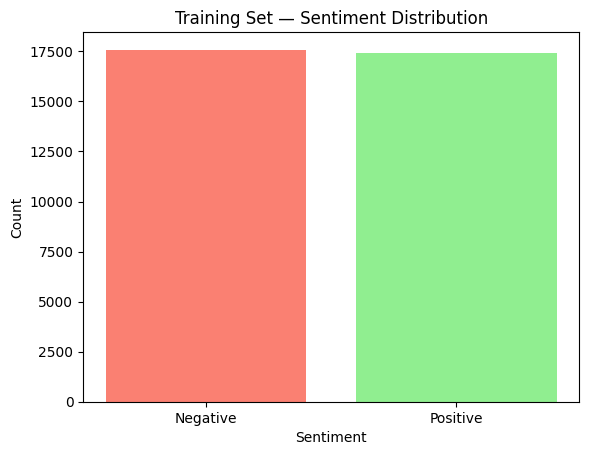

In [ ]:
target_counts = Counter(train_df['sentiment'])
print("Sentiment Distribution:", target_counts)
print(f"Class balance ratio (Negative:Positive): {target_counts[0] / target_counts[1]:.3f}")

plt.bar(target_counts.keys(), target_counts.values(), color=['salmon', 'lightgreen'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Training Set — Sentiment Distribution')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [ ]:
negations = {'not', 'no', 'nor', 'never', 'none', 'neither'}
stop_words = set(stopwords.words('english')) - negations
lemmatizer = WordNetLemmatizer()

# Clean the text: Perform the following preprocessing steps on the tex

In [ ]:
# def preprocess_text(text):
#     """
#     Clean text following PDF guidelines:
#     1. Lowercase
#     2. Remove HTML tags (IMDb-specific)
#     3. Remove URLs
#     4. Remove mentions and hashtags
#     5. Expand contractions
#     6. Remove punctuation and numbers
#     7. Remove stopwords + lemmatize
#     """
#     # 1. Lowercase
#     text = text.lower()

#     # 2. Remove HTML tags (IMDb has <br />)
#     text = re.sub(r'<[^>]+>', ' ', text)

#     # 3. Remove URLs
#     text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

#     # 4. Remove mentions and hashtags
#     text = re.sub(r'\@\w+|\#', '', text)

#     # 5. Expand contractions (PDF requirement)
#     contractions = {
#         "don't": "do not", "doesn't": "does not", "didn't": "did not",
#         "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
#         "couldn't": "could not", "can't": "cannot", "isn't": "is not",
#         "aren't": "are not", "wasn't": "was not", "weren't": "were not",
#         "haven't": "have not", "hasn't": "has not", "i'm": "i am",
#         "you're": "you are", "it's": "it is", "that's": "that is",
#         "n't": " not"
#     }
#     for c, e in contractions.items():
#         text = text.replace(c, e)

#     # 6. Remove punctuation and numbers
#     text = re.sub(r'[^\w\s]', '', text)
#     text = re.sub(r'\d+', '', text)

#     # 7. Remove stopwords and lemmatize
#     stop_words = set(stopwords.words('english'))
#     lemmatizer = WordNetLemmatizer()
#     tokens = text.split()
#     tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
#     return ' '.join(tokens)

# # Test
# sample = train_df['review'].iloc[1]
# cleaned = preprocess_text(sample)
# print("Original:", sample[:200])
# print("\nCleaned :", cleaned[:200])


def preprocess_text(text):
    """
    Clean text following PDF guidelines:
    1. Lowercase
    2. Remove HTML tags (IMDb-specific)
    3. Remove URLs
    4. Remove mentions and hashtags
    5. Expand contractions
    6. Remove punctuation and numbers
    7. Remove stopwords (preserving negations) + lemmatize
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags (IMDb has <br />)
    text = re.sub(r'<[^>]+>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Remove mentions and hashtags
    text = re.sub(r'\@\w+|\#', '', text)

    # 5. Expand contractions (PDF requirement)
    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
        "couldn't": "could not", "can't": "cannot", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "haven't": "have not", "hasn't": "has not", "i'm": "i am",
        "you're": "you are", "it's": "it is", "that's": "that is",
        "n't": " not"
    }
    for c, e in contractions.items():
        text = text.replace(c, e)

    # 6. Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 7. Remove stopwords (negations preserved) and lemmatize
    negations = {'not', 'no', 'nor', 'never', 'none', 'neither'}
    stop_words = set(stopwords.words('english')) - negations
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Test
sample = train_df['review'].iloc[1]
cleaned = preprocess_text(sample)
print("Original:", sample[:200])
print("\nCleaned :", cleaned[:200])

Original: With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, and yet to my horror: Requiem is far worse than I could have imagined.<br /><br />

Cleaned : movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre


In [ ]:
print("Cleaning training set...")
train_df['cleaned_text'] = train_df['review'].apply(preprocess_text)

print("Cleaning validation set...")
val_df['cleaned_text'] = val_df['review'].apply(preprocess_text)

print("Cleaning test set...")
test_df['cleaned_text'] = test_df['review'].apply(preprocess_text)

print("\nDone! Sample comparison:")
print(f"Original: {train_df['review'].iloc[0][:200]}")
print(f"Cleaned : {train_df['cleaned_text'].iloc[0][:200]}")

Cleaning training set...
Cleaning validation set...
Cleaning test set...

Done! Sample comparison:
Original: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
Cleaned : avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical rac


# Visualize the cleaned data: Use tools like a word cloud or display the most frequent words to explore
the cleaned data

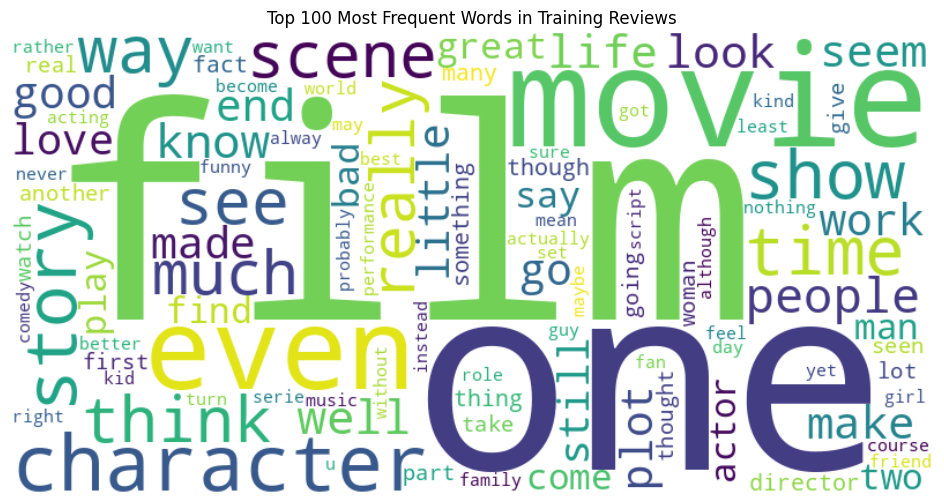

In [ ]:
# Word cloud of all cleaned text
all_words = ' '.join(train_df['cleaned_text'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words in Training Reviews')
plt.show()

In [ ]:
# Sample demonstration first
sample_texts = [
    "I love this movie!",
    "Worst film ever.",
    "Happy with the experience.",
    "Not great, not terrible.",
    "Absolutely fantastic!"
]

demo_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
demo_tokenizer.fit_on_texts(sample_texts)
demo_sequences = demo_tokenizer.texts_to_sequences(sample_texts)
print("Demo Word Index:", demo_tokenizer.word_index)
print("Demo Sequences :", demo_sequences)

Demo Word Index: {'<OOV>': 1, 'not': 2, 'i': 3, 'love': 4, 'this': 5, 'movie': 6, 'worst': 7, 'film': 8, 'ever': 9, 'happy': 10, 'with': 11, 'the': 12, 'experience': 13, 'great': 14, 'terrible': 15, 'absolutely': 16, 'fantastic': 17}
Demo Sequences : [[3, 4, 5, 6], [7, 8, 9], [10, 11, 12, 13], [2, 14, 2, 15], [16, 17]]


# Tokenization and Padding: Convert the cleaned text data into sequences and ensure uniform sequence lengths by applying padding

In [ ]:
# Real tokenizer for our IMDb data
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned_text'])    # fit ONLY on training data

# Convert text to integer sequences for all splits
X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned_text'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['cleaned_text'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned_text'])

print(f"Vocabulary length (full)  : {len(tokenizer.word_index)}")
print(f"Example sequence length   : {len(train_df['cleaned_text'].iloc[100].split())}")

Vocabulary length (full)  : 122386
Example sequence length   : 40


# Sequence length statistics

In [ ]:

print(f"Max sequence length before padding: {max([len(seq) for seq in X_train_seq])}")
seq_lengths = [len(seq) for seq in X_train_seq]

print(f"\nSequence length statistics:")
print(f"  Min     : {np.min(seq_lengths)}")
print(f"  Max     : {np.max(seq_lengths)}")
print(f"  Mean    : {np.mean(seq_lengths):.0f}")
print(f"  Median  : {np.median(seq_lengths):.0f}")
print(f"  95th %  : {np.percentile(seq_lengths, 95):.0f}")
print(f"  99th %  : {np.percentile(seq_lengths, 99):.0f}")

# Use percentile-based padding (PDF requirement)
max_len = int(np.percentile(seq_lengths, 95))
print(f"\nUsing max_len: {max_len}")

# Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

# Convert labels to numpy arrays
y_train = np.array(train_df['sentiment'].values)
y_val   = np.array(val_df['sentiment'].values)
y_test  = np.array(test_df['sentiment'].values)

print(f"\nFinal shapes:")
print(f"  X_train_pad: {X_train_pad.shape}")
print(f"  X_val_pad  : {X_val_pad.shape}")
print(f"  X_test_pad : {X_test_pad.shape}")

Max sequence length before padding: 1433

Sequence length statistics:
  Min     : 4
  Max     : 1433
  Mean    : 120
  Median  : 90
  95th %  : 309
  99th %  : 467

Using max_len: 309

Final shapes:
  X_train_pad: (35000, 309)
  X_val_pad  : (5000, 309)
  X_test_pad : (10000, 309)


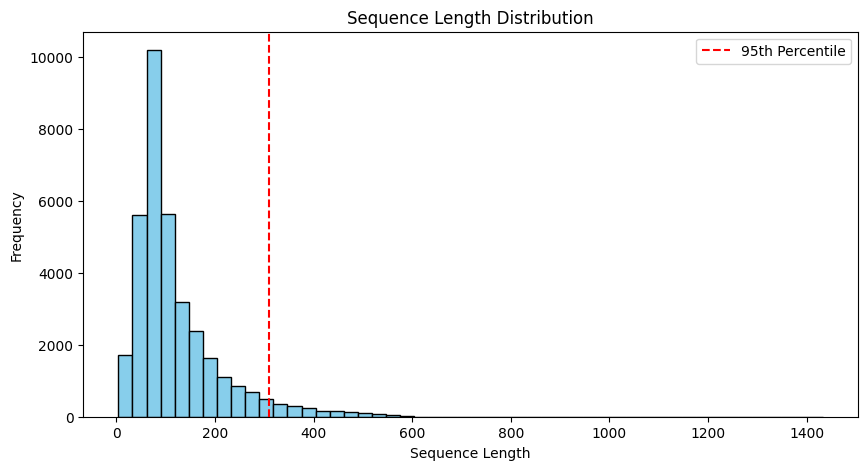

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Sequence Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red',
            linestyle='dashed', label='95th Percentile')
plt.legend()
plt.show()

# Class distribution check

In [ ]:

train_counts = Counter(y_train)
val_counts   = Counter(y_val)
test_counts  = Counter(y_test)

print("── Class distribution ──")
print(f"  Train → Neg: {train_counts[0]}  Pos: {train_counts[1]}")
print(f"  Val   → Neg: {val_counts[0]}   Pos: {val_counts[1]}")
print(f"  Test  → Neg: {test_counts[0]}  Pos: {test_counts[1]}")

# OOV rate on test set
oov_idx = tokenizer.word_index.get("<OOV>", 1)
total_tk_test = X_test_pad[X_test_pad != 0].size
oov_tk_test = (X_test_pad == oov_idx).sum()
print(f"\n── OOV rate on Test Set: {oov_tk_test/total_tk_test*100:.1f}% "
      f"({oov_tk_test}/{total_tk_test} tokens)")

── Class distribution ──
  Train → Neg: 17584  Pos: 17416
  Val   → Neg: 2455   Pos: 2545
  Test  → Neg: 4961  Pos: 5039

── OOV rate on Test Set: 5.4% (62789/1161029 tokens)


# Hyperparameters and Model 1: Simple RNN



In [ ]:

vocab_size    = len(tokenizer.word_index) + 1
embedding_dim = 128
hidden_units  = 64
print("MODEL 1: SimpleRNN model")

model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(units=hidden_units, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_rnn.summary()


MODEL 1: SimpleRNN model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 309, 128)       │    15,665,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,677,953 (59.81 MB)

 Trainable params: 15,677,953 (59.81 MB)

 Non-trainable params: 0 (0.00 B)

# Model 2: LSTM with a trainable Embedding layer

In [ ]:
print("MODEL 2: LSTM model")
model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(units=hidden_units, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
model_lstm.summary()

MODEL 2: LSTM model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 309, 128)       │    15,665,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,715,009 (59.95 MB)

 Trainable params: 15,715,009 (59.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoints_rnn = ModelCheckpoint('rnn_best_model.keras',
                                   monitor='val_loss',
                                   save_best_only=True,
                                   verbose=1)
earlystopping = EarlyStopping(monitor='val_loss', patience=4,
                              verbose=1, restore_best_weights=True)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoints_rnn, earlystopping]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4959 - loss: 0.6974
Epoch 1: val_loss improved from None to 0.69488, saving model to rnn_best_model.keras

Epoch 1: finished saving model to rnn_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 46s 36ms/step - accuracy: 0.5025 - loss: 0.6971 - val_accuracy: 0.5102 - val_loss: 0.6949
Epoch 2/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4976 - loss: 0.6950
Epoch 2: val_loss did not improve from 0.69488
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.5015 - loss: 0.6943 - val_accuracy: 0.4914 - val_loss: 0.6976
Epoch 3/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5011 - loss: 0.6922
Epoch 3: val_loss did not improve from 0.69488
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.5038 - loss: 0.6920 - val_accuracy: 0.4938 - val_loss: 0.6968
Epoch 4/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5156 - loss: 0.6874
Epoch 4: val_loss improved from 0.69488 to 0.

# Model diagnosis

In [ ]:
def model_diagnosis(model, history, X_test_pad, y_test, model_name="Model"):
    y_pred_proba = model.predict(X_test_pad, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

    print(f"DIAGNOSIS: {model_name}")


    # Prediction stats
    print(" Prediction score stats ")
    print(f"  min : {y_pred_proba.min():.4f}")
    print(f"  max : {y_pred_proba.max():.4f}")
    print(f"  mean: {y_pred_proba.mean():.4f}")
    print(f"  std : {y_pred_proba.std():.4f}")

    # Threshold sweep
    print("\n Threshold sweep ")
    print(f"  {'Threshold':<12} {'Pred Pos%':<12} {'Pred Neg%':<12}")
    for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
        preds = (y_pred_proba > t).flatten()
        pp = preds.mean() * 100
        print(f"  {t:<12.1f} {pp:<12.1f} {100-pp:<12.1f}")

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")

    # Classification report
    print("\n Classification report ")
    print(classification_report(y_test, y_pred,
                                target_names=["Negative", "Positive"],
                                zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(" Confusion matrix ")
    print(f"            Pred Neg   Pred Pos")
    print(f"True Neg     {cm[0,0]:<8}    {cm[0,1]}")
    print(f"True Pos     {cm[1,0]:<8}    {cm[1,1]}")

    # Training history plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        ax.plot(history.history[metric], label="train")
        ax.plot(history.history[f"val_{metric}"], label="val")
        ax.set_title(f"{model_name} — {metric}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
DIAGNOSIS: Simple RNN
 Prediction score stats 
  min : 0.1556
  max : 0.7970
  mean: 0.4937
  std : 0.0232

 Threshold sweep 
  Threshold    Pred Pos%    Pred Neg%   
  0.3          99.9         0.1         
  0.4          99.5         0.5         
  0.5          3.5          96.5        
  0.6          1.1          98.9        
  0.7          0.1          99.9        

Accuracy: 0.4988

 Classification report 
              precision    recall  f1-score   support

    Negative       0.50      0.97      0.66      4961
    Positive       0.54      0.04      0.07      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.36     10000
weighted avg       0.52      0.50      0.36     10000

 Confusion matrix 
            Pred Neg   Pred Pos
True Neg     4800        161
True Pos     4851        188


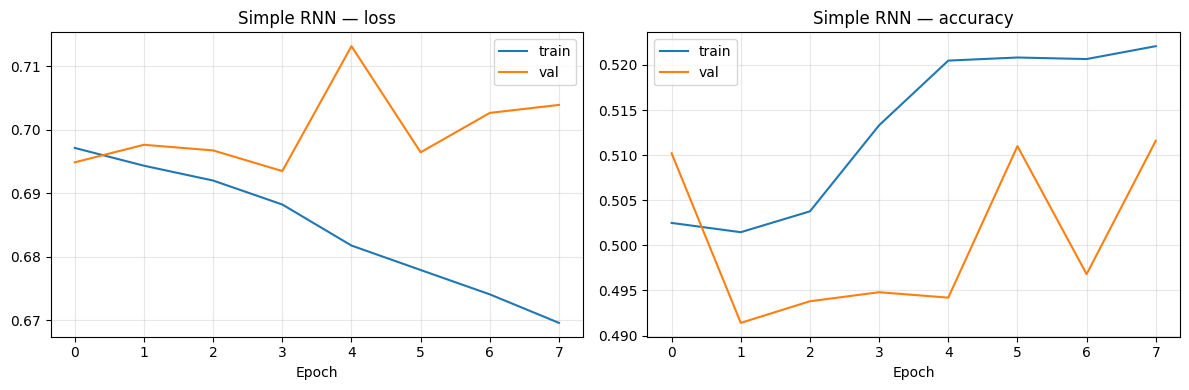

In [ ]:
acc_rnn = model_diagnosis(model_rnn, history_rnn, X_test_pad, y_test, "Simple RNN")

In [ ]:
checkpoints_lstm = ModelCheckpoint('lstm_best_model.keras',
                                    monitor='val_loss',
                                    save_best_only=True,
                                    verbose=1)
earlystopping = EarlyStopping(monitor='val_loss', patience=4,
                              verbose=1, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoints_lstm, earlystopping]
)

Epoch 1/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5105 - loss: 0.6934
Epoch 1: val_loss improved from None to 0.69267, saving model to lstm_best_model.keras

Epoch 1: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.5089 - loss: 0.6932 - val_accuracy: 0.5098 - val_loss: 0.6927
Epoch 2/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5162 - loss: 0.6842
Epoch 2: val_loss did not improve from 0.69267
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.5156 - loss: 0.6824 - val_accuracy: 0.4998 - val_loss: 0.6952
Epoch 3/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5673 - loss: 0.6408
Epoch 3: val_loss improved from 0.69267 to 0.39213, saving model to lstm_best_model.keras

Epoch 3: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.6548 - loss: 0.5709 - val_accuracy: 0.8372 - val_loss: 0.3921
Epoch 4/10
1093/1094 ━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
DIAGNOSIS: LSTM
 Prediction score stats 
  min : 0.0033
  max : 0.9997
  mean: 0.5071
  std : 0.4229

 Threshold sweep 
  Threshold    Pred Pos%    Pred Neg%   
  0.3          55.8         44.2        
  0.4          53.8         46.2        
  0.5          52.3         47.7        
  0.6          50.2         49.8        
  0.7          47.8         52.2        

Accuracy: 0.8772

 Classification report 
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87      4961
    Positive       0.86      0.90      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

 Confusion matrix 
            Pred Neg   Pred Pos
True Neg     4252        709
True Pos     519         4520


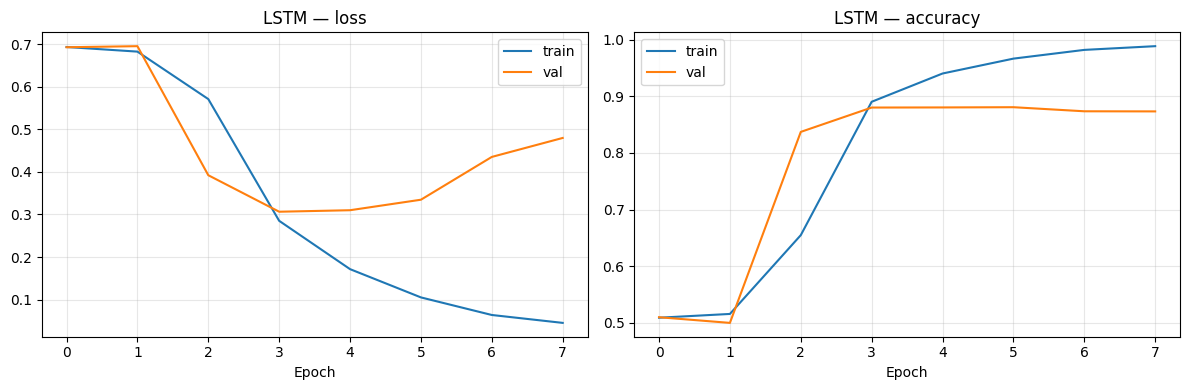

In [ ]:
acc_lstm = model_diagnosis(model_lstm, history_lstm, X_test_pad, y_test, "LSTM")

# LSTM with a trainable Embedding layer

In [ ]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 106.2 MB/s eta 0:00:00


In [ ]:

import gensim.downloader as api
from gensim.models import KeyedVectors

# Load pretrained GloVe embeddings (smaller than Word2Vec — faster)
print("Loading pretrained embeddings...")
word2vec_model = api.load("glove-wiki-gigaword-100")
print(f"Loaded! {len(word2vec_model)} words available")

Loading pretrained embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! 400000 words available


In [ ]:
embedding_dim_w2v = 100   # matches glove-wiki-gigaword-100

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

hit, miss = 0, 0
for word, index in tokenizer.word_index.items():
    if index >= vocab_size:
        continue
    if word in word2vec_model:
        embedding_matrix[index] = word2vec_model[word]
        hit += 1
    else:
        embedding_matrix[index] = np.random.normal(scale=0.6, size=(embedding_dim_w2v,))
        miss += 1

print(f"Found:   {hit} words")
print(f"Missing: {miss} words")
print(f"Matrix shape: {embedding_matrix.shape}")

# Free RAM
import gc
del word2vec_model
gc.collect()
print("word2vec freed from RAM")

Found:   60037 words
Missing: 62349 words
Matrix shape: (122387, 100)
word2vec freed from RAM


# MODEL 3: LSTM with pretrained Word2Vec embeddings

In [ ]:
print("MODEL 3: LSTM with pretrained Word2Vec embeddings")

model_lstm_w2v = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False             # frozen pretrained embeddings
    ),
    LSTM(units=hidden_units, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model_lstm_w2v.compile(optimizer='adam',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])
model_lstm_w2v.summary()

MODEL 3: LSTM with pretrained Word2Vec embeddings


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 309, 100)       │    12,238,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,281,005 (46.85 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 12,238,700 (46.69 MB)

In [ ]:
checkpoints_w2v = ModelCheckpoint('lstm_w2v_best_model.keras',
                                   monitor='val_loss',
                                   save_best_only=True,
                                   verbose=1)
earlystopping = EarlyStopping(monitor='val_loss', patience=4,
                              verbose=1, restore_best_weights=True)

history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoints_w2v, earlystopping]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5096 - loss: 0.6925
Epoch 1: val_loss improved from None to 0.68392, saving model to lstm_w2v_best_model.keras

Epoch 1: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.5108 - loss: 0.6902 - val_accuracy: 0.6150 - val_loss: 0.6839
Epoch 2/10
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6035 - loss: 0.6524
Epoch 2: val_loss improved from 0.68392 to 0.57280, saving model to lstm_w2v_best_model.keras

Epoch 2: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.6367 - loss: 0.6351 - val_accuracy: 0.7412 - val_loss: 0.5728
Epoch 3/10
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6722 - loss: 0.6159
Epoch 3: val_loss did not improve from 0.57280
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.6009 - loss: 0.6507 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 4/10
1090/

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
DIAGNOSIS: LSTM + Word2Vec
 Prediction score stats 
  min : 0.1414
  max : 0.8420
  mean: 0.4783
  std : 0.2182

 Threshold sweep 
  Threshold    Pred Pos%    Pred Neg%   
  0.3          58.4         41.6        
  0.4          58.1         41.9        
  0.5          57.9         42.1        
  0.6          57.4         42.6        
  0.7          2.1          97.9        

Accuracy: 0.7224

 Classification report 
              precision    recall  f1-score   support

    Negative       0.76      0.64      0.70      4961
    Positive       0.70      0.80      0.74      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000

 Confusion matrix 
            Pred Neg   Pred Pos
True Neg     3198        1763
True Pos     1013        4026


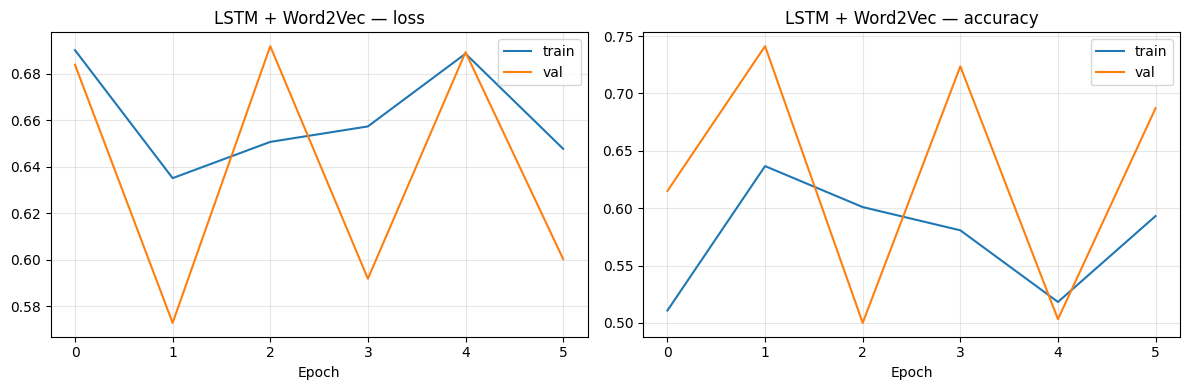

In [ ]:
acc_w2v = model_diagnosis(model_lstm_w2v, history_lstm_w2v, X_test_pad, y_test, "LSTM + Word2Vec")

# Three-model comparison table

FINAL MODEL COMPARISON
          Model Accuracy
     Simple RNN   0.4988
           LSTM   0.8772
LSTM + Word2Vec   0.7224


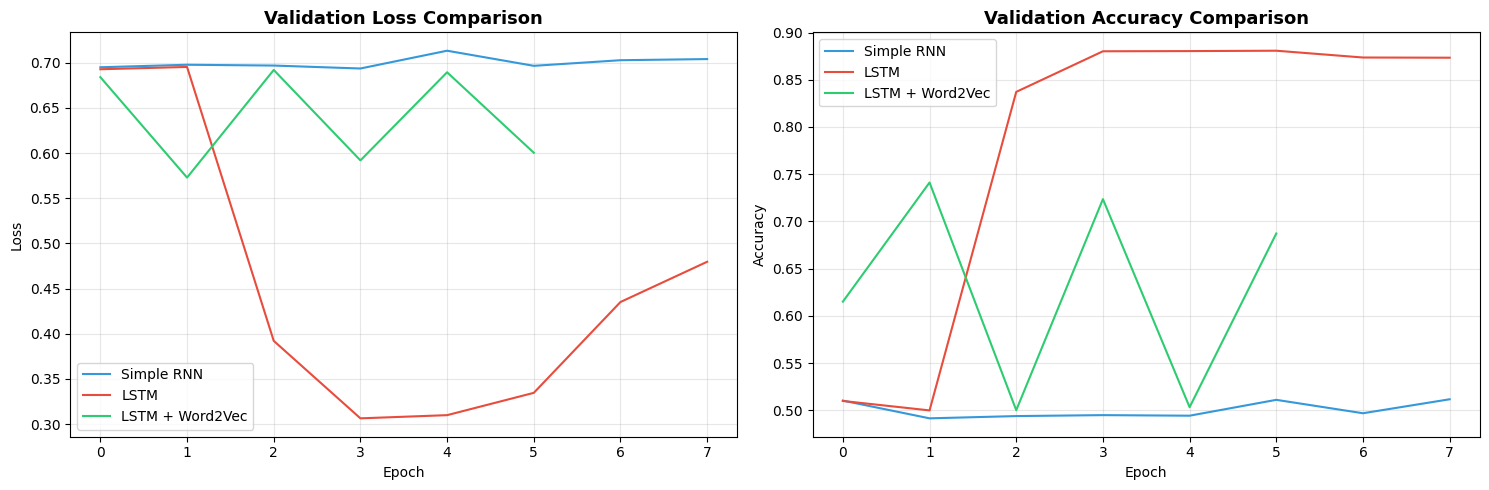

In [ ]:

comparison_df = pd.DataFrame({
    'Model'   : ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_w2v:.4f}']
})

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Visual comparison of training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_rnn.history['val_loss'],     label='Simple RNN',      color='#3498db')
axes[0].plot(history_lstm.history['val_loss'],    label='LSTM',            color='#e74c3c')
axes[0].plot(history_lstm_w2v.history['val_loss'], label='LSTM + Word2Vec', color='#2ecc71')
axes[0].set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history['val_accuracy'],     label='Simple RNN',      color='#3498db')
axes[1].plot(history_lstm.history['val_accuracy'],    label='LSTM',            color='#e74c3c')
axes[1].plot(history_lstm_w2v.history['val_accuracy'], label='LSTM + Word2Vec', color='#2ecc71')
axes[1].set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Use best model (LSTM + Word2Vec) for error analysis

In [ ]:

y_pred_proba = model_lstm_w2v.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

# Find misclassified examples
misclassified_indices = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified_indices)} out of {len(y_test)}")

# Show 3 misclassified examples
print("\n" + "=" * 70)
print("MISCLASSIFIED EXAMPLES — Error Analysis")
print("=" * 70)

for i, idx in enumerate(misclassified_indices[:3]):
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label = "Positive" if y_pred[idx] == 1 else "Negative"
    confidence = y_pred_proba[idx][0]

    print(f"\n--- Example {i+1} ---")
    print(f"True Label : {true_label}")
    print(f"Predicted  : {pred_label} (confidence: {confidence:.4f})")
    print(f"Original Review:\n  {test_df['review'].iloc[idx][:300]}")
    print(f"Cleaned Review:\n  {test_df['cleaned_text'].iloc[idx][:300]}")

Total misclassified: 2776 out of 10000

MISCLASSIFIED EXAMPLES — Error Analysis

--- Example 1 ---
True Label : Negative
Predicted  : Positive (confidence: 0.6609)
Original Review:
  I was very disappointed with this series. It had lots of cool graphics and that's about it. The level of detail it went into was minimal, and I always got the feeling the audience was being patronized -- there was a lot of what seemed to me as "This is extremely cool but we're not going to explain i
Cleaned Review:
  disappointed series lot cool graphic level detail went minimal always got feeling audience patronized lot seemed extremely cool not going explain detail not get anyway let show pretty picture entertain host would drop interestingsounding word sparticles supersymmetry without attempt explaining look 

--- Example 2 ---
True Label : Positive
Predicted  : Negative (confidence: 0.2218)
Original Review:
  Great just great! The West Coast got "Dirty" Harry Callahan, the East Coast got Sharky. Burt R

# Predection on sentiments

In [ ]:
def predict_sentiment(text, model):
    """Predict sentiment of a single review."""
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]
    if prediction > 0.5:
        return "Positive", float(prediction)
    else:
        return "Negative", float(1 - prediction)

# Test with sample reviews
test_reviews = [
    "This movie was absolutely amazing! Great acting and storyline.",
    "Worst film I have ever seen. Total waste of time.",
    "It was okay, nothing special but not terrible either."
]

print("Sample Predictions (using LSTM + Word2Vec):\n")
for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model_lstm_w2v)
    print(f"Review: {review[:80]}")
    print(f"  → {sentiment} (confidence: {confidence:.4f})\n")

Sample Predictions (using LSTM + Word2Vec):

Review: This movie was absolutely amazing! Great acting and storyline.
  → Positive (confidence: 0.6609)

Review: Worst film I have ever seen. Total waste of time.
  → Negative (confidence: 0.7782)

Review: It was okay, nothing special but not terrible either.
  → Negative (confidence: 0.7782)

